# VFB Analysis

## Imports

In [2]:
# %load_ext autoreload
# %autoreload 2
# if think is slowing down, disable autoreload by restarting kernel without it.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


from redoxed.data_loading.data_loaders import LoaderFactory, BiologicLoader, CSVLoader
from redoxed.plots import NyquistPlot, DRTPlot, PolarisationPlot
from redoxed.impedance import EISData, DRTData
from redoxed.DC import PolarisationData


from schemdraw import Drawing

from pyimpspec import (
    ComplexImpedances,    # Alias for a NumPy array of complex128 values
    Frequencies,          # Alias for a NumPy array of float64 values
    Circuit,
    DataSet,
    FitResult,
    Element,              # The base class for all circuit elements
    ElementDefinition,    # A class that contains information regarding a new circuit element
    ParameterDefinition,  # A class that contains information regarding a circuit element's parameter
    register_element,     # A function that processes the new element class
    parse_cdc,
    fit_circuit,
)

from IPython.display import Markdown


# %load_ext autoreload
# %autoreload 2
# if think is slowing down, disable autoreload by restarting kernel without it.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


from redoxed.data_loading.data_loaders import LoaderFactory, BiologicLoader, CSVLoader
from redoxed.plots.eis_plot import NyquistPlot
from redoxed.plots.drt_plot import DRTPlot
from redoxed.plots import ResidualsPlot
from redoxed.impedance import EISData, DRTData

from IPython.display import Markdown

import pyDRTtools




from pyimpspec.analysis.drt.peak_analysis import (
    DRTPeaks,
    _analyze_peaks,
)

def peak_analysis(DRTData_object, num_peaks, peak_positions, disallow_skew):
    time_constants = DRTData_object.tau
    gammas = DRTData_object.gamma
    DRTPeaks_object = _analyze_peaks(
        time_constants, gammas, num_peaks, peak_positions, disallow_skew
    )
    return DRTPeaks_object

# DRT_peak_fit_total = DRTData(tau = DRTPeaks_object.get_time_constants(), gamma = DRTPeaks_object.get_gammas(), label = "Peak fit")
# DRTPeaks_object.peaks[0].get_gammas(time_constants=DRTPeaks_object.get_time_constants())
# df = DRTPeaks_object.to_peaks_dataframe()

import numpy as np

def H_N_Z(f, Z0, tau0, alpha=1, beta=1):
    """
    Havriliak-Negami
    Alpha controls broadening of the spectra, beta controls the asymmetry of the spectra.
    With beta = 1, the H-N function reduces to a ZARC, with alpha=beta=1, it reduces to an RC
    This function is a placeholder for the H-N function.
    It currently does not perform any operations or return any values.
    """
    return Z0*(1+(1j*2*np.pi*f*tau0)**alpha)**(-beta)

def H_N_DRT(tau, Z0, tau0, alpha, beta):
    """
    Havriliak-Negami
    This function is a placeholder for the H-N function.
    It currently does not perform any operations or return any values.
    """
    theta = np.arctan(np.abs((np.sin(np.pi*alpha))/(((tau/tau0)**alpha)+np.cos(np.pi*alpha))))
    return (Z0/np.pi)*((tau/tau0)**(alpha*beta))*np.sin(beta*theta)*(1+((tau/tau0)**(2*alpha))+(2*(tau/tau0)**(alpha))*(np.cos(np.pi*alpha)))**(-beta/2)


import datetime

def ole_to_seconds(ole_timestamp):
    # OLE base date is 1899-12-30
    ole_base = datetime.datetime(1899, 12, 30)
    dt = ole_base + datetime.timedelta(days=ole_timestamp)
    # Convert to seconds since Unix epoch
    unix_epoch = datetime.datetime(1970, 1, 1)
    seconds = (dt - unix_epoch).total_seconds()
    return seconds




%matplotlib inline


Initializing pyDRTtools from c:\users\es758\documents\github\pydrttools
['c:\\Users\\es758\\anaconda3\\envs\\RFB_es758\\python313.zip', 'c:\\Users\\es758\\anaconda3\\envs\\RFB_es758\\DLLs', 'c:\\Users\\es758\\anaconda3\\envs\\RFB_es758\\Lib', 'c:\\Users\\es758\\anaconda3\\envs\\RFB_es758', '', 'c:\\Users\\es758\\anaconda3\\envs\\RFB_es758\\Lib\\site-packages', 'C:\\Users\\es758\\Documents\\GitHub\\redoxED\\src', 'c:\\users\\es758\\documents\\github\\pydrttools', 'c:\\users\\es758\\documents\\github\\nanodrt', 'C:\\Users\\es758\\Documents\\GitHub\\phd_tools', 'c:\\Users\\es758\\anaconda3\\envs\\RFB_es758\\Lib\\site-packages\\win32', 'c:\\Users\\es758\\anaconda3\\envs\\RFB_es758\\Lib\\site-packages\\win32\\lib', 'c:\\Users\\es758\\anaconda3\\envs\\RFB_es758\\Lib\\site-packages\\Pythonwin', 'c:\\Users\\es758\\anaconda3\\envs\\RFB_es758\\Lib\\site-packages\\yadg']
Imported basics
Imported BHT
Imported cli
Imported GUI
Imported HMC
Imported layout
Imported nearest_PD
Imported parameter_sele

## Data

1. Initial go

"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.07.12 VFB_CIP_T400_NR117\1_CIP_24rpm_01_OCV_C04.mpr"
Definitely looks like this grows over pretty much the whole time - messy amongst cycling cell though
"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.07.12 VFB_CIP_T400_NR117\1_CIP_24rpm_02_PEIS_C04.mpr"
"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.07.12 VFB_CIP_T400_NR117\1_FB1_20ml_1600mM_V_22rpm_01_GCPL_C02.mpr"
a bit lower than the next few. Could be because do high SOC hold after, could be because water migration
"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.07.12 VFB_CIP_T400_NR117\1_FB1_20ml_1600mM_V_22rpm_02_GEIS_C02.mpr"
"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.07.12 VFB_CIP_T400_NR117\1_FB1_20ml_1600mM_V_22rpm_03_GCPL_C02.mpr"
"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.07.12 VFB_CIP_T400_NR117\1_FB1_20ml_1600mM_V_22rpm_04_GCPL_C02.mpr"
First 9 eis goes are wrong voltage or something, so look at 10 onwards and see rock solid stability.
"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.07.12 VFB_CIP_T400_NR117\1_FB1_20ml_1600mM_V_22rpm_05_GEIS_C02.mpr"
"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.07.12 VFB_CIP_T400_NR117\1_FB1_20ml_1600mM_V_22rpm_06_GCPL_C02.mpr"
works until cycle 41 where it borks up. Before that, only 67 % utilisation or something but stable performance - even increased for a bit.
"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.07.12 VFB_CIP_T400_NR117\1_FB1_20ml_1600mM_V_22rpm_07_GCPL_C02.mpr"


Can ignore all this data - was me troubleshooting broken potentiostat
"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.07.12 VFB_CIP_T400_NR117\2_FB1_maybehole_C02.mpr"
"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.07.12 VFB_CIP_T400_NR117\3_FB1_maybehole_01_GCPL_C02.mpr"
"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.07.12 VFB_CIP_T400_NR117\3_FB1_maybehole_02_GCPL_C02.mpr"
"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.07.12 VFB_CIP_T400_NR117\4_FB1_channel_test_01_GCPL_C04.mpr"
"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.07.12 VFB_CIP_T400_NR117\4_FB1_channel_test_02_GCPL_C04.mpr"
"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.07.12 VFB_CIP_T400_NR117\5_FB1_deadc2test_01_GCPL_C02.mpr"
"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.07.12 VFB_CIP_T400_NR117\5_FB1_deadc2test_02_GCPL_C02.mpr"
"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.07.12 VFB_CIP_T400_NR117\6_FB1_deadc2test_02_GCPL_C02.mpr"
"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.07.12 VFB_CIP_T400_NR117\6_FB1_testc1_01_GCPL_C01.mpr"
"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.07.12 VFB_CIP_T400_NR117\6_FB1_testc1_02_GCPL_C01.mpr"
"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.07.12 VFB_CIP_T400_NR117\7_FB1_deadc2test_Irange_C02.mpr"
"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.07.12 VFB_CIP_T400_NR117\8_C2_Irange_test_C02.mpr"
"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.07.12 VFB_CIP_T400_NR117\9_C1_Irange_test_C01.mpr"

10. replaced electrolyte - is main test can benchmark with but I have been using later files too
From here until reverse polarity, don't do any cycling, just wander about 50 SOC.
"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.07.12 VFB_CIP_T400_NR117\10_FB1_20ml_1600mM_V_22rpm_newV_01_GCPL_C01.mpr"
"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.07.12 VFB_CIP_T400_NR117\10_FB1_20ml_1600mM_V_22rpm_newV_02_GEIS_C01.mpr"
"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.07.12 VFB_CIP_T400_NR117\10_FB1_20ml_1600mM_V_22rpm_newV_03_GCPL_C01.mpr"
"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.07.12 VFB_CIP_T400_NR117\10_FB1_20ml_1600mM_V_22rpm_newV_04_GCPL_C01.mpr"
"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.07.12 VFB_CIP_T400_NR117\10_FB1_20ml_1600mM_V_22rpm_newV_05_GEIS_C01.mpr"
"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.07.12 VFB_CIP_T400_NR117\10_FB1_20ml_1600mM_V_22rpm_newV_06_GCPL_C01.mpr"
"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.07.12 VFB_CIP_T400_NR117\10_FB1_20ml_1600mM_V_22rpm_newV_07_GEIS_C01.mpr"
"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.07.12 VFB_CIP_T400_NR117\10_FB1_20ml_1600mM_V_22rpm_newV_08_GCPL_C01.mpr"
"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.07.12 VFB_CIP_T400_NR117\10_FB1_20ml_1600mM_V_22rpm_newV_09_GCPL_C01.mpr"
"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.07.12 VFB_CIP_T400_NR117\10_FB2_CIP_24rpm_01_OCV_C04.mpr"
"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.07.12 VFB_CIP_T400_NR117\10_FB2_CIP_24rpm_02_PEIS_C04.mpr"

11. It self-discharged to 1.37 and I used this as another SOC point
"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.07.12 VFB_CIP_T400_NR117\11_FB1_20ml_1600mM_V_22rpm_1p37V_GEIS_C01.mpr"
"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.07.12 VFB_CIP_T400_NR117\11_FB2_CIP_24rpm_GEIS_C04.mpr"

12. Did volt hold at 1.42 rather than 1.421 and ended up being higher resistance than next attempt, so ignore.
"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.07.12 VFB_CIP_T400_NR117\12_FB1_20ml_1600mM_V_22rpm_1p42V_01_GCPL_C01.mpr"
"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.07.12 VFB_CIP_T400_NR117\12_FB1_20ml_1600mM_V_22rpm_1p42V_02_GEIS_C01.mpr"
"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.07.12 VFB_CIP_T400_NR117\12_FB1_20ml_1600mM_V_22rpm_1p42V_03_GCPL_C01.mpr"

13. Quality check of full cell to confirm 50 mA appropriate. 
"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.07.12 VFB_CIP_T400_NR117\13_FB1_20ml_1600mM_V_22rpm_1p421V_quality_01_GCPL_C01.mpr"
"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.07.12 VFB_CIP_T400_NR117\13_FB1_20ml_1600mM_V_22rpm_1p421V_quality_02_GEIS_C01.mpr"
"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.07.12 VFB_CIP_T400_NR117\13_FB1_20ml_1600mM_V_22rpm_1p421V_quality_03_GEIS_C01.mpr"
"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.07.12 VFB_CIP_T400_NR117\13_FB1_20ml_1600mM_V_22rpm_1p421V_quality_04_GEIS_C01.mpr"
"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.07.12 VFB_CIP_T400_NR117\13_FB1_20ml_1600mM_V_22rpm_1p421V_quality_05_GEIS_C01.mpr"
"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.07.12 VFB_CIP_T400_NR117\13_FB1_20ml_1600mM_V_22rpm_1p421V_quality_06_OCV_C01.mpr"
"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.07.12 VFB_CIP_T400_NR117\13_FB1_20ml_1600mM_V_22rpm_1p421V_quality_07_PEIS_C01.mpr"
Low current GEIS and pol of CIP
"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.07.12 VFB_CIP_T400_NR117\13_FB2_CIP_24rpm_pol_01_GEIS_C04.mpr"
"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.07.12 VFB_CIP_T400_NR117\13_FB2_CIP_24rpm_pol_02_GCPL_C04.mpr"

14. Flow rate check
"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.07.12 VFB_CIP_T400_NR117\14_FB1_20ml_1600mM_V_11rpm_1p421V_01_GCPL_C01.mpr"
"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.07.12 VFB_CIP_T400_NR117\14_FB1_20ml_1600mM_V_11rpm_1p421V_02_GEIS_C01.mpr"
"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.07.12 VFB_CIP_T400_NR117\14_FB2_CIP_12rpm_C04.mpr"

15. EIS and pol of full cell - similar to 10. Also quality check of CIP
"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.07.12 VFB_CIP_T400_NR117\15_FB1_20ml_1600mM_V_22rpm_1p421V_01_GCPL_C01.mpr"
"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.07.12 VFB_CIP_T400_NR117\15_FB1_20ml_1600mM_V_22rpm_1p421V_02_GEIS_C01.mpr"
"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.07.12 VFB_CIP_T400_NR117\15_FB1_20ml_1600mM_V_22rpm_1p421V_03_GCPL_C01.mpr"
"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.07.12 VFB_CIP_T400_NR117\15_FB2_CIP_quality_01_GEIS_C01.mpr"
"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.07.12 VFB_CIP_T400_NR117\15_FB2_CIP_quality_02_GEIS_C01.mpr"
"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.07.12 VFB_CIP_T400_NR117\15_FB2_CIP_quality_03_GEIS_C01.mpr"
"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.07.12 VFB_CIP_T400_NR117\15_FB2_CIP_quality_04_GEIS_C01.mpr"
"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.07.12 VFB_CIP_T400_NR117\15_FB2_CIP_quality_05_OCV_C01.mpr"
"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.07.12 VFB_CIP_T400_NR117\15_FB2_CIP_quality_06_PEIS_C01.mpr"

16. Swapped channels, probably same performance just different inductance - Has CIP pol and GEIS.
"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.07.12 VFB_CIP_T400_NR117\16_FB1_20ml_1600mM_V_22rpm_1p421V_swapped_01_GCPL_C04.mpr"
"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.07.12 VFB_CIP_T400_NR117\16_FB1_20ml_1600mM_V_22rpm_1p421V_swapped_02_GEIS_C04.mpr"
"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.07.12 VFB_CIP_T400_NR117\16_FB2_CIP_pol_bias_01_GCPL_C01.mpr"
"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.07.12 VFB_CIP_T400_NR117\16_FB2_CIP_pol_bias_02_GEIS_C01.mpr"

17. Reverse polarisation for first time
"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.07.12 VFB_CIP_T400_NR117\17_FB1_20ml_1600mM_V_22rpm_1p421V_RP_01_GCPL_C04.mpr"
"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.07.12 VFB_CIP_T400_NR117\17_FB1_20ml_1600mM_V_22rpm_1p421V_RP_02_GEIS_C04.mpr"
"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.07.12 VFB_CIP_T400_NR117\17_FB1_20ml_1600mM_V_22rpm_1p421V_RP_03_GCPL_C04.mpr"
positive quality check
"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.07.12 VFB_CIP_T400_NR117\17_FB2_CIP_quality_1p40V_01_GEIS_C01.mpr"
"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.07.12 VFB_CIP_T400_NR117\17_FB2_CIP_quality_1p40V_02_GEIS_C01.mpr"
"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.07.12 VFB_CIP_T400_NR117\17_FB2_CIP_quality_1p40V_03_GEIS_C01.mpr"
"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.07.12 VFB_CIP_T400_NR117\17_FB2_CIP_quality_1p40V_04_GEIS_C01.mpr"
"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.07.12 VFB_CIP_T400_NR117\17_FB2_CIP_quality_1p40V_05_OCV_C01.mpr"
"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.07.12 VFB_CIP_T400_NR117\17_FB2_CIP_quality_1p40V_06_PEIS_C01.mpr"

18. repeat because I didn't believe what I was seeing - with volt hold was less accurate to 50 SOC here than 17 I think.
"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.07.12 VFB_CIP_T400_NR117\18_FB1_20ml_1600mM_V_22rpm_1p421V_RP_repeat_01_GCPL_C04.mpr"
"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.07.12 VFB_CIP_T400_NR117\18_FB1_20ml_1600mM_V_22rpm_1p421V_RP_repeat_02_GEIS_C04.mpr"
"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.07.12 VFB_CIP_T400_NR117\18_FB2_CIP_24rpm_01_GCPL_C01.mpr"
"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.07.12 VFB_CIP_T400_NR117\18_FB2_CIP_24rpm_02_GEIS_C01.mpr"

19. Replaced electorlyte and got results simular to 17. 
"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.07.12 VFB_CIP_T400_NR117\19_FB1_20ml_1600mM_V_22rpm_1p421V_newV_01_GCPL_C04.mpr"
"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.07.12 VFB_CIP_T400_NR117\19_FB1_20ml_1600mM_V_22rpm_1p421V_newV_02_GEIS_C04.mpr"
"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.07.12 VFB_CIP_T400_NR117\19_FB1_20ml_1600mM_V_22rpm_1p421V_newV_03_GCPL_C04.mpr"
"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.07.12 VFB_CIP_T400_NR117\19_FB1_20ml_1600mM_V_22rpm_1p421V_newV_04_GEIS_C04.mpr"
"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.07.12 VFB_CIP_T400_NR117\19_FB1_20ml_1600mM_V_22rpm_1p421V_newV_05_GCPL_C04.mpr"
Flow rate check for CIP positive.
"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.07.12 VFB_CIP_T400_NR117\19_FB2_CIP_12rpm_C01.mpr"

20. Best data for CIP positive pol, EIS, and bias
"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.07.12 VFB_CIP_T400_NR117\20_FB1_20ml_1600mM_V_22rpm_1p421V_01_GCPL_C04.mpr"
"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.07.12 VFB_CIP_T400_NR117\20_FB1_20ml_1600mM_V_22rpm_1p421V_02_GEIS_C04.mpr"
"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.07.12 VFB_CIP_T400_NR117\20_FB2_CIP_24rpm_pol_bias_01_GCPL_C01.mpr"
"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.07.12 VFB_CIP_T400_NR117\20_FB2_CIP_24rpm_pol_bias_02_GEIS_C01.mpr"
"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.07.12 VFB_CIP_T400_NR117\20_FB2_CIP_24rpm_pol_bias_03_GEIS_C01.mpr"

21. CIP positive at 1.37 V.
"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.07.12 VFB_CIP_T400_NR117\21_FB1_20ml_1600mM_V_22rpm_1p37V_01_GCPL_C04.mpr"
"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.07.12 VFB_CIP_T400_NR117\21_FB1_20ml_1600mM_V_22rpm_1p37V_02_GEIS_C04.mpr"
"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.07.12 VFB_CIP_T400_NR117\21_FB2_CIP_24rpm_1p37V_C01.mpr"

22. Re reversed polarity. SHowed growth in both full cell and negative, but I am not sure I got the right soc. Previous reversal suggests could have been ok. 
"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.07.12 VFB_CIP_T400_NR117\22_FB1_20ml_1600mM_V_22rpm_RP_01_GCPL_C04.mpr"
"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.07.12 VFB_CIP_T400_NR117\22_FB1_20ml_1600mM_V_22rpm_RP_02_GEIS_C04.mpr"
"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.07.12 VFB_CIP_T400_NR117\23_FB1_20ml_1600mM_V_22rpm_1p42V_C04.mpr"
"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.07.12 VFB_CIP_T400_NR117\23_FB2_CIP_24rpm_1p421V_neg_C01.mpr"
"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.07.12 VFB_CIP_T400_NR117\24_FB1_20ml_1600mM_V_22rpm_1p421V_C04.mpr"

3.0
10
3.0
10.0


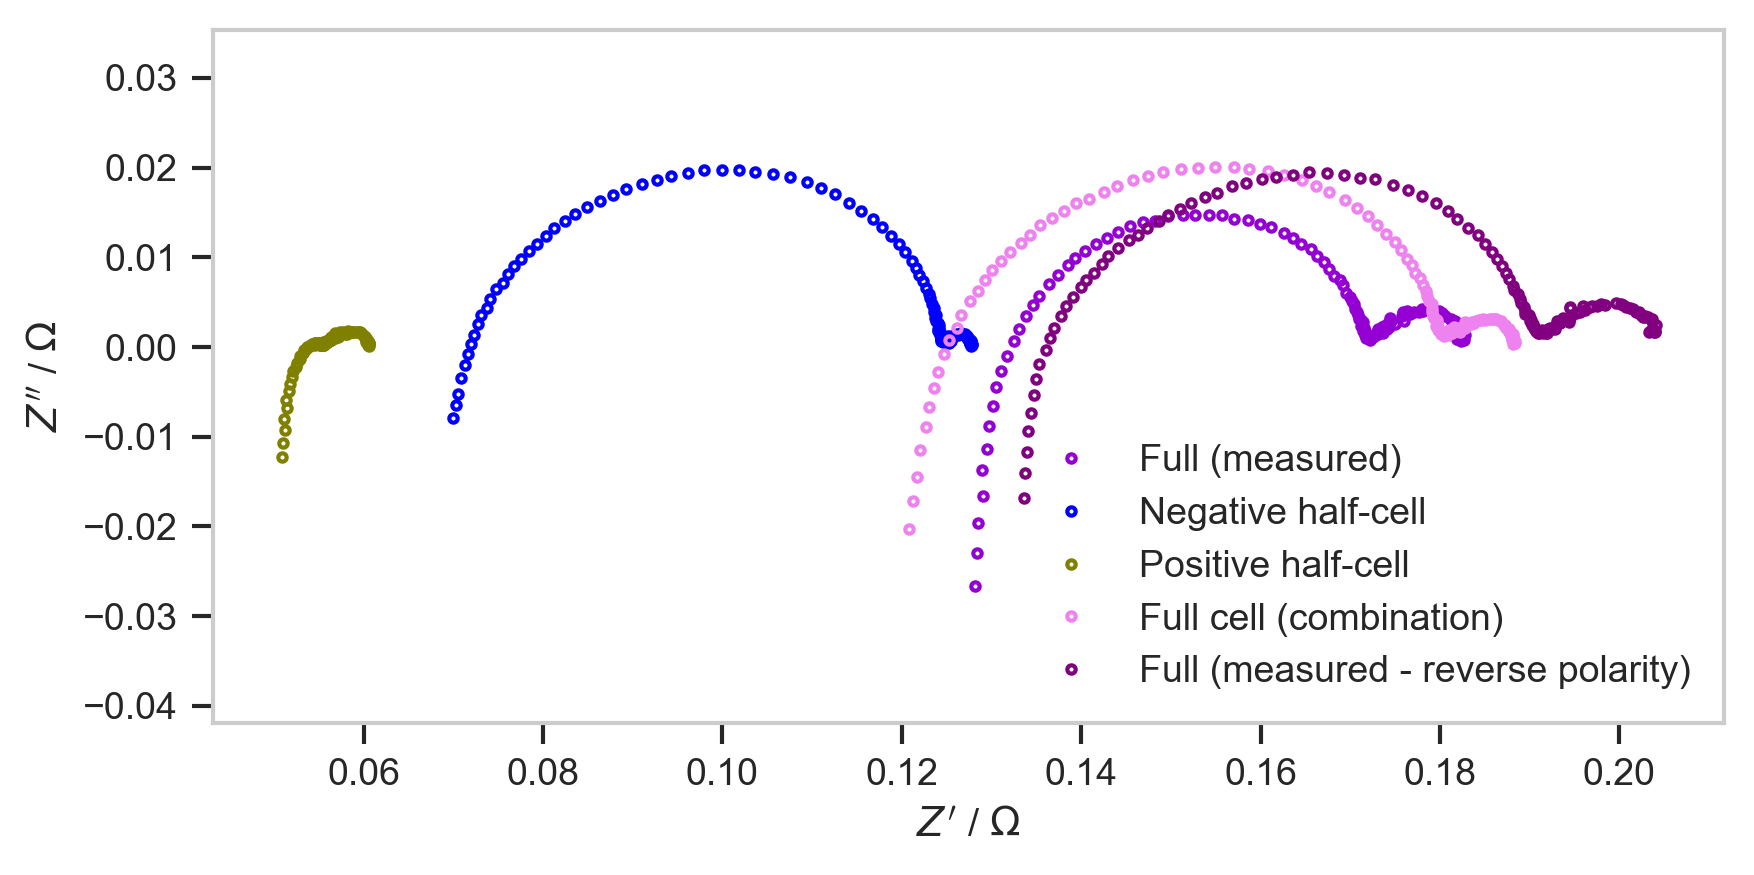

In [10]:

EISData_array = []
fitted_EISData_array = []
DRTData_array = []
R_array = []
L_array = []

fpath = r"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.07.12 VFB_CIP_T400_NR117\15_FB1_20ml_1600mM_V_22rpm_1p421V_02_GEIS_C01.mpr"
label = "Full (measured)"
ECData_object = BiologicLoader().load_data(fpath=fpath)
print(max(ECData_object.df["cycle number"]))
ECData_object.df = ECData_object.filter_by_col("cycle number", lambda value: value == 2)
EISData_object = ECData_object.to_EISData()
EISData_object.label = label
EISData_array.append(EISData_object)


fpath = r"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.07.12 VFB_CIP_T400_NR117\16_FB2_CIP_pol_bias_02_GEIS_C01.mpr"
label = "Negative half-cell"
ECData_object = BiologicLoader().load_data(fpath=fpath)
print(max(ECData_object.df["Ns"]))
# display(ECData_object.df)
ECData_object.df = ECData_object.filter_by_col("Ns", lambda value: value == 0)
EISData_object = ECData_object.to_EISData()
# halve the Z values
EISData_object.Z = EISData_object.Z/2
Z_neg = EISData_object.Z.copy()  # Store the Z values for the negative half-cell
f_neg = EISData_object.f.copy()  # Store the frequency values for the negative half-cell
EISData_object._calculate_z_quants()
EISData_object.label = label
EISData_array.append(EISData_object)


fpath = r"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.07.12 VFB_CIP_T400_NR117\20_FB2_CIP_24rpm_pol_bias_02_GEIS_C01.mpr"
label = "Positive half-cell"
ECData_object = BiologicLoader().load_data(fpath=fpath)
print(max(ECData_object.df["cycle number"]))
ECData_object.df = ECData_object.filter_by_col("cycle number", lambda value: value == 3)
EISData_object = ECData_object.to_EISData()
# halve the Z values
EISData_object.Z = EISData_object.Z/2
Z_pos = EISData_object.Z.copy()  # Store the Z values for the positive half-cell
f_pos = EISData_object.f.copy()  # Store the frequency values for the positive half-cell
EISData_object._calculate_z_quants()
EISData_object.label = label
EISData_array.append(EISData_object)


Z_synth = Z_pos + Z_neg
f_synth = (f_pos + f_neg)/2 # Average the frequency values for the synthetic data
EISData_object = EISData(Z=Z_synth, f=f_synth, label="Full cell (combination)")
EISData_array.append(EISData_object)


fpath = r"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.07.12 VFB_CIP_T400_NR117\20_FB1_20ml_1600mM_V_22rpm_1p421V_02_GEIS_C04.mpr"
label = "Full (measured - reverse polarity)"
ECData_object = BiologicLoader().load_data(fpath=fpath)
print(max(ECData_object.df["cycle number"]))
ECData_object.df = ECData_object.filter_by_col("cycle number", lambda value: value == 1)
EISData_object = ECData_object.to_EISData()
EISData_object.label = label
EISData_array.append(EISData_object)

# fpath = r"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.07.12 VFB_CIP_T400_NR117\22_FB1_20ml_1600mM_V_22rpm_RP_02_GEIS_C04.mpr"
# label = "Full (measured - re-reverse polarity)"
# ECData_object = BiologicLoader().load_data(fpath=fpath)
# print(max(ECData_object.df["cycle number"]))
# ECData_object.df = ECData_object.filter_by_col("cycle number", lambda value: value == 1)
# EISData_object = ECData_object.to_EISData()
# EISData_object.label = label
# EISData_array.append(EISData_object)


# fpath = r"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.07.12 VFB_CIP_T400_NR117\23_FB2_CIP_24rpm_1p421V_neg_C01.mpr"
# label = "Negative half-cell 2"
# ECData_object = BiologicLoader().load_data(fpath=fpath)
# print(max(ECData_object.df["cycle number"]))
# # display(ECData_object.df)
# ECData_object.df = ECData_object.filter_by_col("cycle number", lambda value: value == 1)
# EISData_object = ECData_object.to_EISData()
# # halve the Z values
# EISData_object.Z = EISData_object.Z/2
# Z_neg2 = EISData_object.Z.copy()  # Store the Z values for the negative half-cell
# f_neg2 = EISData_object.f.copy()  # Store the frequency values for the negative half-cell
# EISData_object._calculate_z_quants()
# EISData_object.label = label
# EISData_array.append(EISData_object)

# Generate a color array using a colormap
num_colors = 3  # Number of colors needed
colors = plt.cm.viridis(np.linspace(0, 1, num_colors))  # Use the 'viridis' colormap
colors = plt.cm.hsv(np.linspace(0, 1, num_colors))  # Use the 'hsv' colormap
cmap = plt.get_cmap('plasma')
colors = cmap(np.linspace(0, 1, num_colors))
colors = ['darkviolet', 'blue', 'olive', 'violet', 'purple', 'indigo', 'darkblue']  # Example color names

NyquistPlot_object = NyquistPlot(figsize=(6.5, 3), dpi=300) 

for i, EISData_object in enumerate(EISData_array):
    # EISData_object.trim_inductive()
    #EISData_object.crop_frequency(1, 8e3)
    EISData_object.crop_frequency(0.01, 1e5)
    # NyquistPlot_object.add_plot(EISData_object, linestyle = "", marker = "o", markersize = 1, color = colors[i], zorder = 3)
    NyquistPlot_object.add_plot(EISData_object, linestyle = "", marker = "o",markerfacecolor = 'none', markeredgecolor =colors[i], markersize = 2, zorder = 3)

### Plot formatting
## Ensure ratio equal
# data_plot.ax.set_aspect("equal", adjustable="datalim")  # if enable, overall fig size will be strictly enforced, but x and y limits will be overwritten. So will padding of labels I think.
# data_plot.ax.set_aspect('equal',adjustable='box') # if enable this, fig size will get overwritten, at least in y. but can set x and y lim
## Cropping
# data_plot.ax.set_ylim([0.01, None]) # can always edit afterwards like most settings with something like
## Embellishments
#data_plot.add_major_ticks(major_tick_spacing = 0.05)
# data_plot.add_minor_ticks(major_tick_spacing = 5)
# data_plot.ax.grid(True)
# data_plot.ax.legend(bbox_to_anchor=(0., 0.9), loc="upper left") # manual legend settings
NyquistPlot_object.ax.legend()

display(NyquistPlot_object.fig)



## Hyperparameter selection

10.0


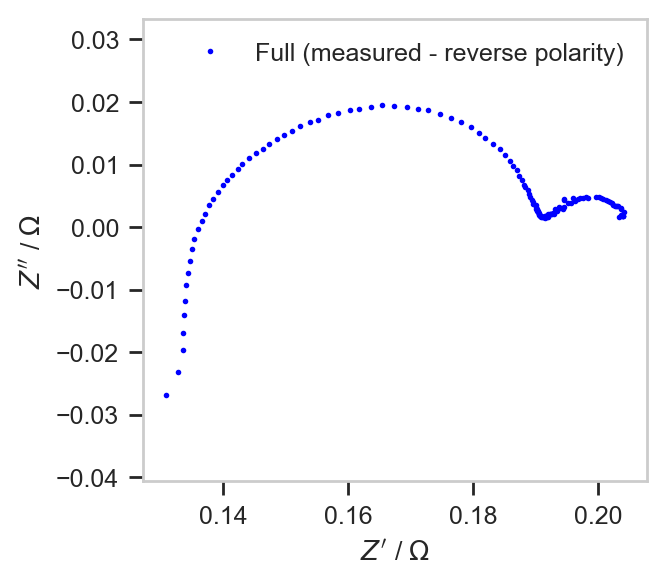

ed's tau adjustment made


c:\users\es758\documents\github\pydrttools\pyDRTtools\basics.py:59: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  out_val = integrate.quad(integrand_g_i, -50, 50, epsabs=1E-9, epsrel=1E-9)


The value of the regularization parameter is 1e-07
     pcost       dcost       gap    pres   dres
 0: -4.5081e+00 -5.0329e+00  2e+02  1e+01  9e-05
 1: -3.9452e+00 -5.8818e+00  2e+01  2e+00  1e-05
 2: -4.1651e+00 -5.3463e+00  1e+00  2e-02  1e-07
 3: -4.3447e+00 -4.8390e+00  5e-01  5e-03  4e-08
 4: -4.4248e+00 -4.7926e+00  4e-01  2e-03  1e-08
 5: -4.4959e+00 -4.5469e+00  5e-02  9e-05  7e-10
 6: -4.5063e+00 -4.5170e+00  1e-02  1e-05  9e-11
 7: -4.5083e+00 -4.5112e+00  3e-03  2e-17  1e-16
 8: -4.5086e+00 -4.5090e+00  5e-04  1e-17  4e-17
 9: -4.5086e+00 -4.5087e+00  1e-04  3e-17  2e-16
10: -4.5086e+00 -4.5086e+00  1e-05  9e-18  3e-16
11: -4.5086e+00 -4.5086e+00  3e-06  3e-17  7e-17
Optimal solution found.
R = 0.130987063201937, L = 3.401731275158127e-08, lambda = 1e-07
The value of the regularization parameter is 1e-06
     pcost       dcost       gap    pres   dres
 0: -4.5081e+00 -5.0329e+00  2e+02  1e+01  9e-05
 1: -3.9452e+00 -5.8818e+00  2e+01  2e+00  1e-05
 2: -4.1651e+00 -5.3463e+00

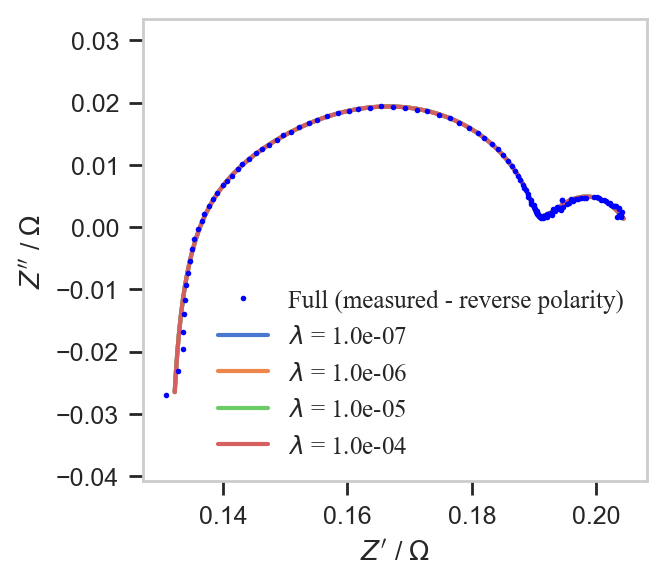

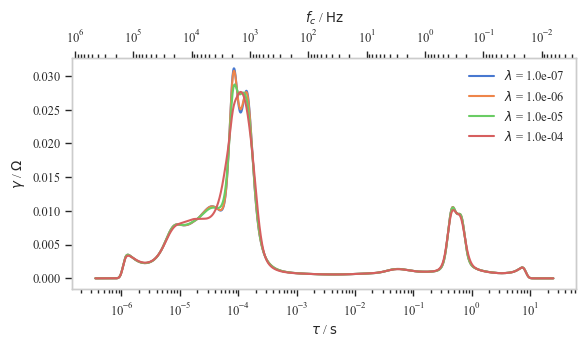

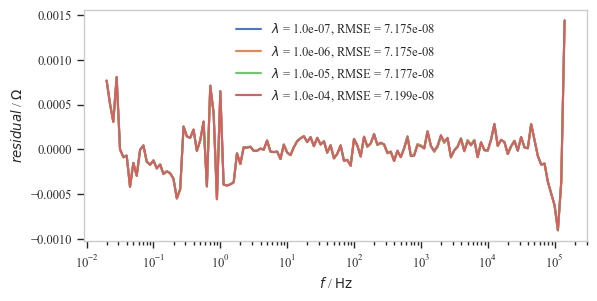

In [38]:
EISData_array = []

# fpath = r"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.07.12 VFB_CIP_T400_NR117\16_FB2_CIP_pol_bias_02_GEIS_C01.mpr"
# label = "Negative symmetric-cell"
# ECData_object = BiologicLoader().load_data(fpath=fpath)
# print(max(ECData_object.df["Ns"]))
# # display(ECData_object.df)
# ECData_object.df = ECData_object.filter_by_col("Ns", lambda value: value == 0)
# EISData_object = ECData_object.to_EISData()
# # halve the Z values
# # EISData_object.Z = EISData_object.Z/2
# # Z_neg = EISData_object.Z.copy()  # Store the Z values for the negative half-cell
# # f_neg = EISData_object.f.copy()  # Store the frequency values for the negative half-cell
# # EISData_object._calculate_z_quants()
# EISData_object.label = label
# EISData_array.append(EISData_object)

# fpath = r"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.07.12 VFB_CIP_T400_NR117\20_FB2_CIP_24rpm_pol_bias_02_GEIS_C01.mpr"
# label = "Positive half-cell"
# ECData_object = BiologicLoader().load_data(fpath=fpath)
# print(max(ECData_object.df["cycle number"]))
# ECData_object.df = ECData_object.filter_by_col("cycle number", lambda value: value == 3)
# EISData_object = ECData_object.to_EISData()
# # halve the Z values
# # EISData_object.Z = EISData_object.Z/2
# # Z_pos = EISData_object.Z.copy()  # Store the Z values for the positive half-cell
# # f_pos = EISData_object.f.copy()  # Store the frequency values for the positive half-cell
# # EISData_object._calculate_z_quants()
# EISData_object.label = label
# EISData_array.append(EISData_object)

# fpath = r"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.07.12 VFB_CIP_T400_NR117\15_FB1_20ml_1600mM_V_22rpm_1p421V_02_GEIS_C01.mpr"
# label = "Full (measured)"
# ECData_object = BiologicLoader().load_data(fpath=fpath)
# print(max(ECData_object.df["cycle number"]))
# ECData_object.df = ECData_object.filter_by_col("cycle number", lambda value: value == 2)
# EISData_object = ECData_object.to_EISData()
# EISData_object.label = label
# EISData_array.append(EISData_object)

fpath = r"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.07.12 VFB_CIP_T400_NR117\20_FB1_20ml_1600mM_V_22rpm_1p421V_02_GEIS_C04.mpr"
label = "Full (measured - reverse polarity)"
ECData_object = BiologicLoader().load_data(fpath=fpath)
print(max(ECData_object.df["cycle number"]))
ECData_object.df = ECData_object.filter_by_col("cycle number", lambda value: value == 1)
EISData_object = ECData_object.to_EISData()
EISData_object.label = label
EISData_array.append(EISData_object)

NyquistPlot_object = NyquistPlot(figsize=(3.25, 3), dpi=200) 

for i, EISData_object in enumerate(EISData_array):
    # EISData_object.trim_inductive()
    EISData_object.crop_frequency(0.01, 1.5e5)
    NyquistPlot_object.add_plot(EISData_object, linestyle = "", marker = "o", markersize = 1, color = 'blue', zorder = 3)

### Plot formatting
## Ensure ratio equal
# data_plot.ax.set_aspect("equal", adjustable="datalim")  # if enable, overall fig size will be strictly enforced, but x and y limits will be overwritten. So will padding of labels I think.
# data_plot.ax.set_aspect('equal',adjustable='box') # if enable this, fig size will get overwritten, at least in y. but can set x and y lim
## Cropping
# data_plot.ax.set_ylim([0.01, None]) # can always edit afterwards like most settings with something like
## Embellishments
#data_plot.add_major_ticks(major_tick_spacing = 0.05)
# data_plot.add_minor_ticks(major_tick_spacing = 5)
# data_plot.ax.grid(True)
# data_plot.ax.legend(bbox_to_anchor=(0., 0.9), loc="upper left") # manual legend settings
NyquistPlot_object.ax.legend()

display(NyquistPlot_object.fig)

# Load measurement data into EIS_object
pyDRTtools_EIS_object = pyDRTtools.runs.EIS_object(
    EISData_object.f, EISData_object.Z_re, EISData_object.Z_im, ed_adjust = True
)
# this includes tau definition of
# # self.tau = 1/freq # we assume that the collocation points equal to 1/freq as default
# # self.tau_fine  = np.logspace(log10(self.tau.min())-0.5,log10(self.tau.max())+0.5,10*freq.shape[0])

lambda_array = np.logspace(-7, -2, num = 6, base=10)
lambda_array = np.logspace(-7, -4, num = 4, base=10)

DRTPlot_object = DRTPlot(figsize=(6.5, 3), dpi=100) 

ResidualsPlot_object = ResidualsPlot(figsize=(6.5, 3), dpi=100)

for i in range(len(lambda_array)):
    lambda_0 = lambda_array[i] # initial guess

    induct_used = 1 # 1 means do keep inductive and fit inductance.
    der_used = '1st order'
    cv_type = 'custom' # fix lambda

    reg_param = lambda_0
    shape_control = "FWHM Coefficient" # otherwise coeff is treated as their definition of shape factor mu
    coeff = 0.5 # FWHM twice log spacing means coef 0.5. Is done so there is good overlap.
    rbf_type = "Gaussian" # Gaussian is the default, but can also use 'Cauchy', 'Lorentzian', 'Exponential', 'Polynomial', 'Ridge' or 'Laplacian'
    data_used = "Combined Re-Im Data"
    # ridge regression DRT
    fitted_entry = pyDRTtools.runs.simple_run(
        entry=pyDRTtools_EIS_object,
        rbf_type=rbf_type,
        data_used=data_used,
        induct_used=induct_used,
        der_used=der_used,
        cv_type=cv_type,
        reg_param=reg_param,
        shape_control=shape_control,
        coeff=coeff,
    )
    ### If want to mute the console, can use something like this with simple_run nested in
    # # Redirecting stdout to capture the output
    # with io.StringIO() as output, contextlib.redirect_stdout(output):

    gamma_pyDRTtools = fitted_entry.gamma # is tau_fine from DRTtools, not tau used for fitting x. padded values.
    tau_pyDRTtools = fitted_entry.out_tau_vec
    DRT_object_pyDRTtools = DRTData(tau = tau_pyDRTtools, gamma = gamma_pyDRTtools, label = EISData_object.label)
    R_pyDRTtools = fitted_entry.R
    L_pyDRTtools = fitted_entry.L
    lambda_value_pyDRTtools = fitted_entry.lambda_value 
    f_pyDRTtools = fitted_entry.freq
    Z_pyDRTtools = fitted_entry.mu_Z_re + 1j*fitted_entry.mu_Z_im
    res_re_pyDRTtools = fitted_entry.res_re # absolute difference between the real part of the measured and fitted data
    rmse_res_re_pyDRTtools = np.sum(res_re_pyDRTtools**2)/len(res_re_pyDRTtools) # root mean square error of the real part of the impedance
    EISData_fitted_pyDRTtools = EISData(f = fitted_entry.freq, Z = Z_pyDRTtools, label = EISData_object.label + " DRT")

    print(f"R = {R_pyDRTtools}, L = {L_pyDRTtools}, lambda = {lambda_value_pyDRTtools}")

    NyquistPlot_object.add_plot(EISData_fitted_pyDRTtools, linestyle = "-", marker = "", markersize = 1, label = f"$\\lambda$ = {lambda_value_pyDRTtools:.1e}")

    
    DRTPlot_object.add_plot(DRT_object_pyDRTtools, linestyle = "-", marker = "", label = f"$\\lambda$ = {lambda_value_pyDRTtools:.1e}")

    
    ResidualsPlot_object.add_plot(f=f_pyDRTtools, 
                    residual = res_re_pyDRTtools, 
                    linestyle = "-", 
                    marker = "", 
                    #label = "$\lambda$ = " + str(lambda_value_pyDRTtools)+", RMSE = " + str(rmse_res_re_pyDRTtools)) 
                    label=f"$\\lambda$ = {lambda_value_pyDRTtools:.1e}, RMSE = {rmse_res_re_pyDRTtools:.3e}"
    )  


    # print(res_re_pyDRTtools)
    # print(Z_pyDRTtools.real)
    # print(EISData_object.Z.real)

NyquistPlot_object.ax.legend()
display(NyquistPlot_object.fig)


### Plot formatting
## Cropping
# data_plot.ax.set_ylim([0.01, None]) 
## Embellishments
# data_plot.add_major_ticks(major_tick_spacing = 0.1)
# data_plot.add_minor_ticks(major_tick_spacing = 5)
# data_plot.ax.grid(True)
# data_plot.ax.legend(bbox_to_anchor=(0., 0.9), loc="upper left") # manual legend settings
DRTPlot_object.ax.legend()

DRTPlot_object.add_fc_axis()
display(DRTPlot_object.fig)

ResidualsPlot_object.ax.legend()

display(ResidualsPlot_object.fig)

## Peak ID

10
3.0
3.0
10.0


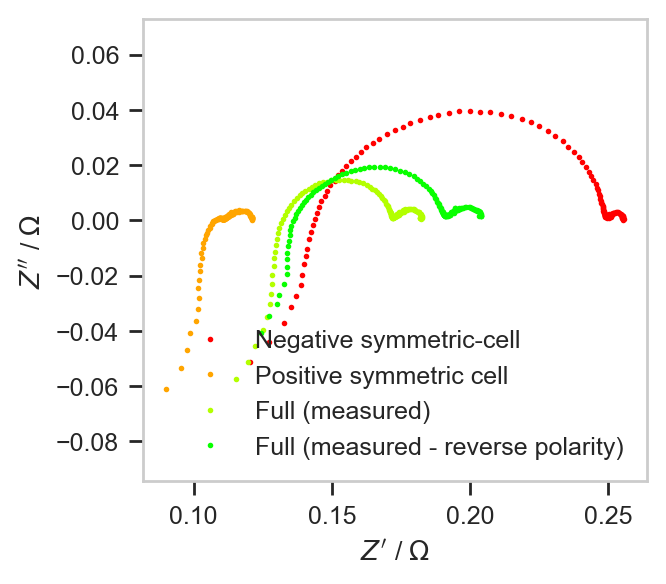

ed's tau adjustment made


c:\users\es758\documents\github\pydrttools\pyDRTtools\basics.py:59: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  out_val = integrate.quad(integrand_g_i, -50, 50, epsabs=1E-9, epsrel=1E-9)


The value of the regularization parameter is 1e-05
     pcost       dcost       gap    pres   dres
 0: -7.2033e+00 -7.9581e+00  2e+02  1e+01  3e-05
 1: -6.6427e+00 -8.7934e+00  2e+01  2e+00  4e-06
 2: -6.8601e+00 -8.2085e+00  2e+00  2e-02  4e-08
 3: -7.0407e+00 -7.5908e+00  6e-01  5e-03  1e-08
 4: -7.1161e+00 -7.5198e+00  4e-01  2e-03  4e-09
 5: -7.1831e+00 -7.2488e+00  7e-02  2e-04  5e-10
 6: -7.2001e+00 -7.2191e+00  2e-02  1e-06  3e-12
 7: -7.2032e+00 -7.2057e+00  2e-03  8e-08  2e-13
 8: -7.2037e+00 -7.2050e+00  1e-03  7e-09  2e-14
 9: -7.2038e+00 -7.2040e+00  2e-04  8e-10  2e-15
10: -7.2038e+00 -7.2039e+00  5e-05  5e-17  3e-17
11: -7.2038e+00 -7.2038e+00  9e-06  3e-17  1e-17
12: -7.2038e+00 -7.2038e+00  2e-06  6e-17  2e-16
Optimal solution found.
R = 0.10914700861855982, L = 5.770896778297488e-08, lambda = 1e-05
ed's tau adjustment made
The value of the regularization parameter is 1e-05
     pcost       dcost       gap    pres   dres
 0: -1.7812e+00 -2.0320e+00  2e+02  1e+01  2e-05


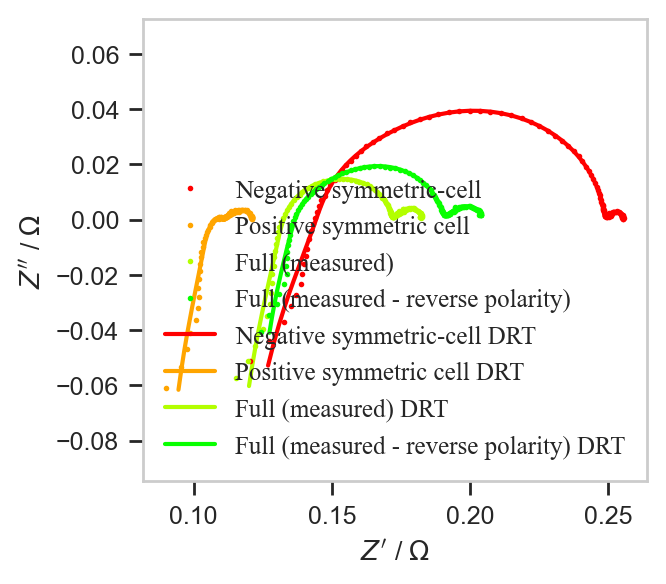

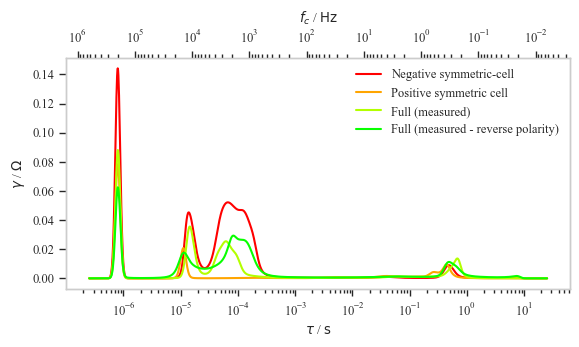

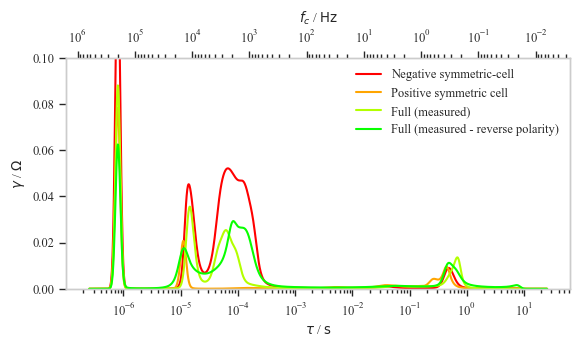

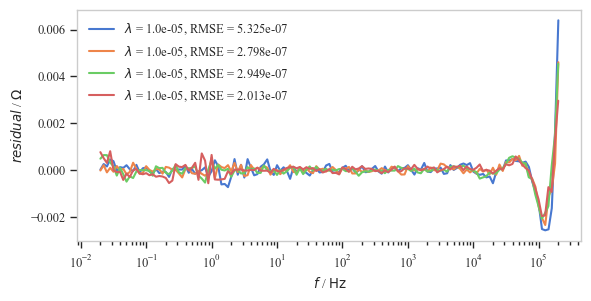

In [ ]:
EISData_array = []
fitted_EISData_array = []
DRTData_array = []
R_array = []
L_array = []

lambda_0 = 1e-5

fpath = r"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.07.12 VFB_CIP_T400_NR117\16_FB2_CIP_pol_bias_02_GEIS_C01.mpr"
label = "Negative symmetric-cell"
ECData_object = BiologicLoader().load_data(fpath=fpath)
print(max(ECData_object.df["Ns"]))
# display(ECData_object.df)
ECData_object.df = ECData_object.filter_by_col("Ns", lambda value: value == 0)
EISData_object = ECData_object.to_EISData()
# halve the Z values
# EISData_object.Z = EISData_object.Z/2
# Z_neg = EISData_object.Z.copy()  # Store the Z values for the negative half-cell
# f_neg = EISData_object.f.copy()  # Store the frequency values for the negative half-cell
# EISData_object._calculate_z_quants()
EISData_object.label = label
EISData_array.append(EISData_object)

fpath = r"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.07.12 VFB_CIP_T400_NR117\20_FB2_CIP_24rpm_pol_bias_02_GEIS_C01.mpr"
label = "Positive symmetric cell"
ECData_object = BiologicLoader().load_data(fpath=fpath)
print(max(ECData_object.df["cycle number"]))
ECData_object.df = ECData_object.filter_by_col("cycle number", lambda value: value == 3)
EISData_object = ECData_object.to_EISData()
# halve the Z values
# EISData_object.Z = EISData_object.Z/2
# Z_pos = EISData_object.Z.copy()  # Store the Z values for the positive half-cell
# f_pos = EISData_object.f.copy()  # Store the frequency values for the positive half-cell
# EISData_object._calculate_z_quants()
EISData_object.label = label
EISData_array.append(EISData_object)

# fpath = r"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.07.12 VFB_CIP_T400_NR117\15_FB1_20ml_1600mM_V_22rpm_1p421V_02_GEIS_C01.mpr"
# label = "Full (measured)"
# ECData_object = BiologicLoader().load_data(fpath=fpath)
# print(max(ECData_object.df["cycle number"]))
# ECData_object.df = ECData_object.filter_by_col("cycle number", lambda value: value == 2)
# EISData_object = ECData_object.to_EISData()
# EISData_object.label = label
# EISData_array.append(EISData_object)

# fpath = r"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.07.12 VFB_CIP_T400_NR117\20_FB1_20ml_1600mM_V_22rpm_1p421V_02_GEIS_C04.mpr"
# label = "Full (measured - reverse polarity)"
# ECData_object = BiologicLoader().load_data(fpath=fpath)
# print(max(ECData_object.df["cycle number"]))
# ECData_object.df = ECData_object.filter_by_col("cycle number", lambda value: value == 1)
# EISData_object = ECData_object.to_EISData()
# EISData_object.label = label
# EISData_array.append(EISData_object)

# Generate a color array using a colormap
num_colors = 10  # Number of colors needed
colors = plt.cm.viridis(np.linspace(0, 1, num_colors))  # Use the 'viridis' colormap
colors = plt.cm.hsv(np.linspace(0, 1, num_colors))  # Use the 'hsv' colormap


NyquistPlot_object = NyquistPlot(figsize=(3.25, 3), dpi=200) 

for i, EISData_object in enumerate(EISData_array):
    # EISData_object.trim_inductive()
    #EISData_object.crop_frequency(1, 8e3)
    EISData_object.crop_frequency(0.01, 2e5)
    NyquistPlot_object.add_plot(EISData_object, linestyle = "", marker = "o", markersize = 1, color = colors[i], zorder = 3)

### Plot formatting
## Ensure ratio equal
# data_plot.ax.set_aspect("equal", adjustable="datalim")  # if enable, overall fig size will be strictly enforced, but x and y limits will be overwritten. So will padding of labels I think.
# data_plot.ax.set_aspect('equal',adjustable='box') # if enable this, fig size will get overwritten, at least in y. but can set x and y lim
## Cropping
# data_plot.ax.set_ylim([0.01, None]) # can always edit afterwards like most settings with something like
## Embellishments
#data_plot.add_major_ticks(major_tick_spacing = 0.05)
# data_plot.add_minor_ticks(major_tick_spacing = 5)
# data_plot.ax.grid(True)
# data_plot.ax.legend(bbox_to_anchor=(0., 0.9), loc="upper left") # manual legend settings
NyquistPlot_object.ax.legend()

display(NyquistPlot_object.fig)



DRTPlot_object = DRTPlot(figsize=(6.5, 3), dpi=100) 

ResidualsPlot_object = ResidualsPlot(figsize=(6.5, 3), dpi=100)

for i, EISData_object in enumerate(EISData_array):
    # Load measurement data into EIS_object
    pyDRTtools_EIS_object = pyDRTtools.runs.EIS_object(
        EISData_object.f, EISData_object.Z_re, EISData_object.Z_im, ed_adjust = True
    )
    # this includes tau definition of
    # # self.tau = 1/freq # we assume that the collocation points equal to 1/freq as default
    # # self.tau_fine  = np.logspace(log10(self.tau.min())-0.5,log10(self.tau.max())+0.5,10*freq.shape[0]
    
    lambda_0 = lambda_0 # initial guess

    induct_used = 1 # 1 means do keep inductive and fit inductance.
    der_used = '1st order'
    cv_type = 'custom' # fix lambda

    reg_param = lambda_0
    shape_control = "FWHM Coefficient" # otherwise coeff is treated as their definition of shape factor mu
    coeff = 0.5 # FWHM twice log spacing means coef 0.5. Is done so there is good overlap.
    rbf_type = "Gaussian" # Gaussian is the default, but can also use 'Cauchy', 'Lorentzian', 'Exponential', 'Polynomial', 'Ridge' or 'Laplacian'
    data_used = "Combined Re-Im Data"
    # ridge regression DRT
    fitted_entry = pyDRTtools.runs.simple_run(
        entry=pyDRTtools_EIS_object,
        rbf_type=rbf_type,
        data_used=data_used,
        induct_used=induct_used,
        der_used=der_used,
        cv_type=cv_type,
        reg_param=reg_param,
        shape_control=shape_control,
        coeff=coeff,
    )
    ### If want to mute the console, can use something like this with simple_run nested in
    # # Redirecting stdout to capture the output
    # with io.StringIO() as output, contextlib.redirect_stdout(output):

    gamma_pyDRTtools = fitted_entry.gamma # is tau_fine from DRTtools, not tau used for fitting x. padded values.
    tau_pyDRTtools = fitted_entry.out_tau_vec
    DRT_object_pyDRTtools = DRTData(tau = tau_pyDRTtools, gamma = gamma_pyDRTtools, label = EISData_object.label)
    R_pyDRTtools = fitted_entry.R
    L_pyDRTtools = fitted_entry.L
    lambda_value_pyDRTtools = fitted_entry.lambda_value 
    f_pyDRTtools = fitted_entry.freq
    Z_pyDRTtools = fitted_entry.mu_Z_re + 1j*fitted_entry.mu_Z_im
    res_re_pyDRTtools = fitted_entry.res_re # absolute difference between the real part of the measured and fitted data
    rmse_res_re_pyDRTtools = np.sum(res_re_pyDRTtools**2)/len(res_re_pyDRTtools) # root mean square error of the real part of the impedance
    EISData_fitted_pyDRTtools = EISData(f = fitted_entry.freq, Z = Z_pyDRTtools, label = EISData_object.label + " DRT")

    fitted_EISData_array.append(EISData_fitted_pyDRTtools)
    DRTData_array.append(DRT_object_pyDRTtools)
    R_array.append(R_pyDRTtools)
    L_array.append(L_pyDRTtools)

    print(f"R = {R_pyDRTtools}, L = {L_pyDRTtools}, lambda = {lambda_value_pyDRTtools}")

    NyquistPlot_object.add_plot(EISData_fitted_pyDRTtools, linestyle = "-", marker = "", markersize = 1, color = colors[i])

    
    DRTPlot_object.add_plot(DRT_object_pyDRTtools, linestyle = "-", marker = "", color = colors[i])

    
    ResidualsPlot_object.add_plot(f=f_pyDRTtools, 
                    residual = res_re_pyDRTtools, 
                    linestyle = "-", 
                    marker = "", 
                    #label = "$\lambda$ = " + str(lambda_value_pyDRTtools)+", RMSE = " + str(rmse_res_re_pyDRTtools)) 
                    label=f"$\\lambda$ = {lambda_value_pyDRTtools:.1e}, RMSE = {rmse_res_re_pyDRTtools:.3e}"
    )  


    # print(res_re_pyDRTtools)
    # print(Z_pyDRTtools.real)
    # print(EISData_object.Z.real)

NyquistPlot_object.ax.legend()
display(NyquistPlot_object.fig)


DRTPlot_object.ax.legend()

DRTPlot_object.add_fc_axis()
display(DRTPlot_object.fig)
### Plot formatting
## Cropping
# data_plot.ax.set_ylim([0.01, None]) 
DRTPlot_object.ax.set_ylim([0, 0.1])
## Embellishments
# data_plot.add_major_ticks(major_tick_spacing = 0.1)
# data_plot.add_minor_ticks(major_tick_spacing = 5)
# data_plot.ax.grid(True)
# data_plot.ax.legend(bbox_to_anchor=(0., 0.9), loc="upper left") # manual legend settings

display(DRTPlot_object.fig)

ResidualsPlot_object.ax.legend()

display(ResidualsPlot_object.fig)

## Half cells